In [1]:
# ============================================================
# H4 - PATIENT AGE GROUP vs REPORTED MEDIAN ED LENGTH OF STAY
# ============================================================
# Research question : Does reported median ED LOS differ across patient age groups?
# Null hypothesis   : Median LOS is equal across all age categories.
# Alternative       : At least one age category differs in median LOS.
# Method            : Frequency-weighted Kruskal-Wallis H test with Dunn post-hoc
#
# Age_Sex has no Explorer CSV, so this notebook reads the cleaned master workbook.
#
# The test itself is NOT reimplemented here. It is imported from
# backend.analytics.statistics.weighted, the same engine the API serves, so this
# notebook and the production endpoint cannot report different numbers.

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Resolve the project root so the notebook runs from any working directory.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "backend").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "Explorer Dataset"
CLEAN_DIR = RAW_DIR / "cleaned"
WORKBOOK = PROJECT_ROOT / "data" / "cleaned dataset" / "Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"

ALPHA = 0.05

print("Project root :", PROJECT_ROOT)
print("Alpha        :", ALPHA)

Project root : C:\Users\amitd\Downloads\Desktoppp\UNF\UNF Assignment _ Notes_Class Practise\Term 5\Capstone\Github\Capstone_Project-DAMO-6994-
Alpha        : 0.05


In [3]:
# Age_Sex exists only in the cleaned master workbook, not as an Explorer CSV.
df = pd.read_excel(WORKBOOK, sheet_name="Age_Sex")

print("Source sheet :", WORKBOOK.name, "-> Age_Sex")
print("Shape        :", df.shape)

Source sheet : Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx -> Age_Sex
Shape        : (190, 8)


In [4]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,sex,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2003-2004,2003,Female,0–17,Pediatric Population,611154,101,1.68
1,2003-2004,2003,Female,18–34,Young Adult Population,532768,127,2.12
2,2003-2004,2003,Female,35–49,Adult Population,503478,129,2.15
3,2003-2004,2003,Female,50–64,Pre-Senior Population,349504,141,2.35
4,2003-2004,2003,Female,65–85+,Geriatric Population,478789,203,3.38
5,2003-2004,2003,Male,0–17,Pediatric Population,702232,101,1.68
6,2003-2004,2003,Male,18–34,Young Adult Population,471173,114,1.90
7,2003-2004,2003,Male,35–49,Adult Population,509323,123,2.05
8,2003-2004,2003,Male,50–64,Pre-Senior Population,351182,140,2.33
9,2003-2004,2003,Male,65–85+,Geriatric Population,396791,188,3.13


In [5]:
print("COLUMN NAMES AND TYPES")
print("-" * 80)

display(pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing": [int(df[c].isna().sum()) for c in df.columns],
}))

COLUMN NAMES AND TYPES
--------------------------------------------------------------------------------


,Column,Data_Type,Missing
0,fiscal_year,str,0
1,fiscal_year_start,int64,0
2,sex,str,0
3,age_group,str,0
4,population_category,str,0
5,ed_visits,int64,0
6,median_los_minutes,int64,0
7,median_los_hours,float64,0


In [6]:
print("DATA QUALITY CHECKS")
print("-" * 80)

print(f"Rows              : {len(df):,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Total missing     : {df.isna().sum().sum():,}")

if "ed_visits" in df.columns:
    print(f"ED visits <= 0    : {(df['ed_visits'] <= 0).sum():,}")
    print(f"Total ED visits   : {df['ed_visits'].sum():,.0f}")

if "median_los_minutes" in df.columns:
    print(f"LOS < 0           : {(df['median_los_minutes'] < 0).sum():,}")

DATA QUALITY CHECKS
--------------------------------------------------------------------------------
Rows              : 190
Duplicate rows    : 0
Total missing     : 0
ED visits <= 0    : 0
Total ED visits   : 175,762,944
LOS < 0           : 0


In [7]:
from backend.analytics.statistics.weighted import (
    weighted_dunn_post_hoc,
    weighted_kruskal_wallis,
    weighted_mean,
    weighted_median,
)

print("Weighted engine imported from backend.analytics.statistics.weighted")

Weighted engine imported from backend.analytics.statistics.weighted


In [8]:
print("AGE CATEGORY VOCABULARY")
print("-" * 80)

age_summary = (
    df.groupby(["population_category", "age_group"], dropna=False)["ed_visits"]
    .agg(["count", "sum"])
    .reset_index()
    .rename(columns={"count": "records", "sum": "total_ed_visits"})
)

display(age_summary)

AGE CATEGORY VOCABULARY
--------------------------------------------------------------------------------


,population_category,age_group,records,total_ed_visits
0,Adult Population,35–49,38,32135738
1,Geriatric Population,65–85+,38,37213696
2,Pediatric Population,0–17,38,38908652
3,Pre-Senior Population,50–64,38,31036789
4,Young Adult Population,18–34,38,36468069


In [9]:
# Life-stage order, so post-hoc pairs read youngest to oldest rather than alphabetically.
AGE_CATEGORY_ORDER = [
    "Pediatric Population",
    "Young Adult Population",
    "Adult Population",
    "Pre-Senior Population",
    "Geriatric Population",
]

h4_df = df.dropna(subset=["population_category", "ed_visits", "median_los_minutes"]).copy()
h4_df = h4_df[(h4_df["ed_visits"] > 0) & (h4_df["median_los_minutes"] >= 0)]

observed = list(h4_df["population_category"].unique())
order = [a for a in AGE_CATEGORY_ORDER if a in observed]
order += sorted([a for a in observed if a not in AGE_CATEGORY_ORDER])

print("H4 ANALYSIS DATASET")
print("=" * 80)
print(f"Original records        : {len(df):,}")
print(f"Records after filtering : {len(h4_df):,}")
print()

for cat in order:
    n = (h4_df["population_category"] == cat).sum()
    v = h4_df.loc[h4_df["population_category"] == cat, "ed_visits"].sum()
    print(f"  {cat:26} {n:>4,} records   {v:>14,.0f} visits")

H4 ANALYSIS DATASET
Original records        : 190
Records after filtering : 190

  Pediatric Population         38 records       38,908,652 visits
  Young Adult Population       38 records       36,468,069 visits
  Adult Population             38 records       32,135,738 visits
  Pre-Senior Population        38 records       31,036,789 visits
  Geriatric Population         38 records       37,213,696 visits


In [10]:
groups, names, wts = [], [], []

for cat in order:
    sub = h4_df[h4_df["population_category"] == cat]
    if sub.empty:
        continue
    groups.append(sub["median_los_minutes"].tolist())
    wts.append(sub["ed_visits"].tolist())
    names.append(cat)

h4_summary = pd.DataFrame([
    {
        "age_category": n,
        "records": len(g),
        "total_ed_visits": int(sum(w)),
        "weighted_mean_los_minutes": round(weighted_mean(g, w), 2),
        "weighted_median_los_minutes": round(weighted_median(g, w), 2),
        "minimum_los_minutes": min(g),
        "maximum_los_minutes": max(g),
    }
    for n, g, w in zip(names, groups, wts)
])

display(h4_summary)

,age_category,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,Pediatric Population,38,38908652,127.70,123.0,101,172
1,Young Adult Population,38,36468069,154.18,151.0,114,204
2,Adult Population,38,32135738,163.94,158.0,123,216
3,Pre-Senior Population,38,31036789,181.32,175.0,140,229
4,Geriatric Population,38,37213696,258.29,250.0,188,326


In [11]:
h4_result = weighted_kruskal_wallis(groups, names, wts)

print("H4 - WEIGHTED KRUSKAL-WALLIS TEST")
print("-" * 80)
print(f"Test statistic (H)     : {h4_result['h_statistic']:.6f}")
print(f"Degrees of freedom     : {h4_result['degrees_of_freedom']}")
print(f"P-value                : {h4_result['p_value']:.10f}")
print(f"Total frequency weight : {h4_result['weighted_n']:,}")
print(f"Tie correction         : {h4_result['tie_correction']:.10f}")

assert 0 < h4_result["tie_correction"] <= 1.0, "tie correction out of bounds"

H4 - WEIGHTED KRUSKAL-WALLIS TEST
--------------------------------------------------------------------------------
Test statistic (H)     : 127422397.976114
Degrees of freedom     : 4
P-value                : 0.0000000000
Total frequency weight : 175,762,944
Tie correction         : 0.9997837399


In [12]:
p_value = h4_result["p_value"]

print("=" * 80)
print("H4 HYPOTHESIS DECISION")
print("=" * 80)
print("Significance level (alpha):", ALPHA)
print(f"P-value: {p_value:.10f}")
print()

if p_value < ALPHA:
    print("Decision: REJECT H0")
    print()
    print("Conclusion:")
    print("There is statistically significant evidence that reported median ED length")
    print("of stay differs across patient age categories.")
else:
    print("Decision: FAIL TO REJECT H0")
    print()
    print("Conclusion:")
    print("There is insufficient evidence that reported median ED length of stay")
    print("differs across patient age categories.")

H4 HYPOTHESIS DECISION
Significance level (alpha): 0.05
P-value: 0.0000000000

Decision: REJECT H0

Conclusion:
There is statistically significant evidence that reported median ED length
of stay differs across patient age categories.


In [13]:
epsilon_squared = h4_result["epsilon_squared"]

print("H4 EFFECT SIZE")
print("-" * 80)
print(f"Epsilon squared (eps^2): {epsilon_squared:.10f}")

if epsilon_squared < 0.01:
    band = "Negligible"
elif epsilon_squared < 0.06:
    band = "Small"
elif epsilon_squared < 0.14:
    band = "Medium"
else:
    band = "Large"

print(f"Magnitude: {band}")

H4 EFFECT SIZE
--------------------------------------------------------------------------------
Epsilon squared (eps^2): 0.7249673606
Magnitude: Large


In [14]:
dunn = weighted_dunn_post_hoc(groups, names, wts, alpha=ALPHA)

dunn_table = pd.DataFrame(dunn)[
    ["group_a", "group_b", "z_score", "p_raw", "p_adj_bonferroni", "significant"]
]

print("H4 - DUNN POST-HOC (BONFERRONI ADJUSTED)")
print("-" * 80)
print(f"Comparisons: {len(dunn)}   Significant: {int(dunn_table['significant'].sum())}")
print()

display(dunn_table)

H4 - DUNN POST-HOC (BONFERRONI ADJUSTED)
--------------------------------------------------------------------------------
Comparisons: 10   Significant: 10



,group_a,group_b,z_score,p_raw,p_adj_bonferroni,significant
0,Pediatric Population,Young Adult Population,3427.0635,0.0,0.0,True
1,Pediatric Population,Adult Population,4458.3098,0.0,0.0,True
2,Pediatric Population,Pre-Senior Population,6279.9193,0.0,0.0,True
3,Pediatric Population,Geriatric Population,10864.8794,0.0,0.0,True
4,Young Adult Population,Adult Population,1127.6654,0.0,0.0,True
5,Young Adult Population,Pre-Senior Population,2954.3402,0.0,0.0,True
6,Young Adult Population,Geriatric Population,7301.4756,0.0,0.0,True
7,Adult Population,Pre-Senior Population,1782.7208,0.0,0.0,True
8,Adult Population,Geriatric Population,5931.9203,0.0,0.0,True
9,Pre-Senior Population,Geriatric Population,4030.6960,0.0,0.0,True


In [15]:
h4_result_table = pd.DataFrame({
    "Hypothesis": ["H4"],
    "Research_Question": ["Does reported median ED LOS differ across patient age groups?"],
    "Test": ["Weighted Kruskal-Wallis"],
    "H_Statistic": [h4_result["h_statistic"]],
    "Degrees_of_Freedom": [h4_result["degrees_of_freedom"]],
    "Weighted_N": [h4_result["weighted_n"]],
    "P_Value": [p_value],
    "Epsilon_Squared": [epsilon_squared],
    "Alpha": [ALPHA],
    "Decision": ["Reject H0" if p_value < ALPHA else "Fail to Reject H0"],
})

display(h4_result_table)

,Hypothesis,Research_Question,Test,H_Statistic,Degrees_of_Freedom,Weighted_N,P_Value,Epsilon_Squared,Alpha,Decision
0,H4,Does reported median ED LOS differ across pati...,Weighted Kruskal-Wallis,1.274224e+08,4,175762944,0.0,0.724967,0.05,Reject H0


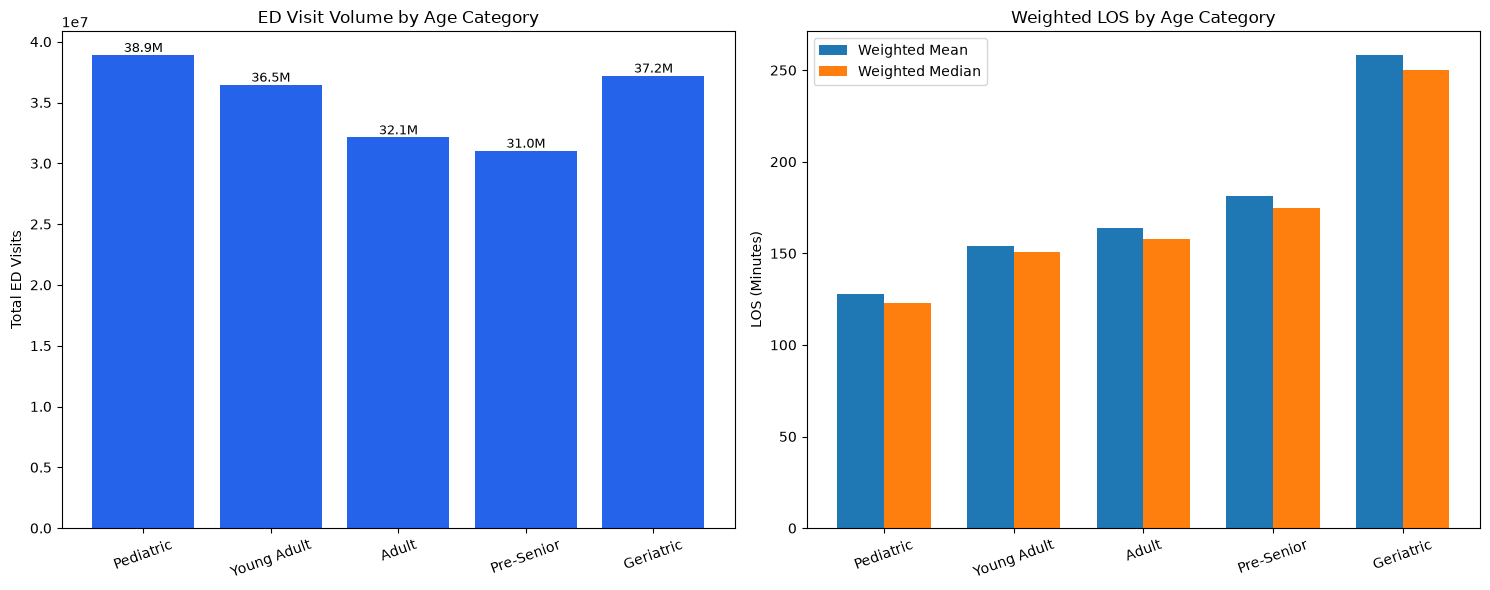

In [16]:
short = [n.replace(" Population", "") for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(short, h4_summary["total_ed_visits"], color="#2563EB")
axes[0].set_ylabel("Total ED Visits")
axes[0].set_title("ED Visit Volume by Age Category")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(h4_summary["total_ed_visits"]):
    axes[0].text(i, v, f"{v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

x = np.arange(len(short))
width = 0.36
axes[1].bar(x - width / 2, h4_summary["weighted_mean_los_minutes"], width, label="Weighted Mean")
axes[1].bar(x + width / 2, h4_summary["weighted_median_los_minutes"], width, label="Weighted Median")
axes[1].set_xticks(x)
axes[1].set_xticklabels(short, rotation=20)
axes[1].set_ylabel("LOS (Minutes)")
axes[1].set_title("Weighted LOS by Age Category")
axes[1].legend()

plt.tight_layout()
plt.show()

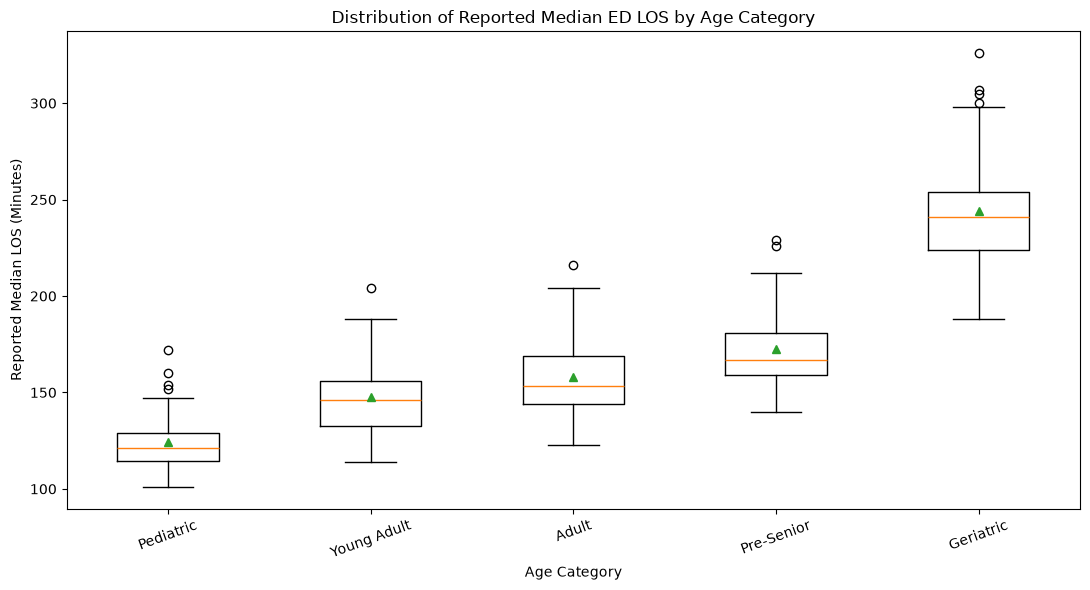

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.boxplot([np.array(g) for g in groups], tick_labels=short, showmeans=True)
ax.set_xlabel("Age Category")
ax.set_ylabel("Reported Median LOS (Minutes)")
ax.set_title("Distribution of Reported Median ED LOS by Age Category")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

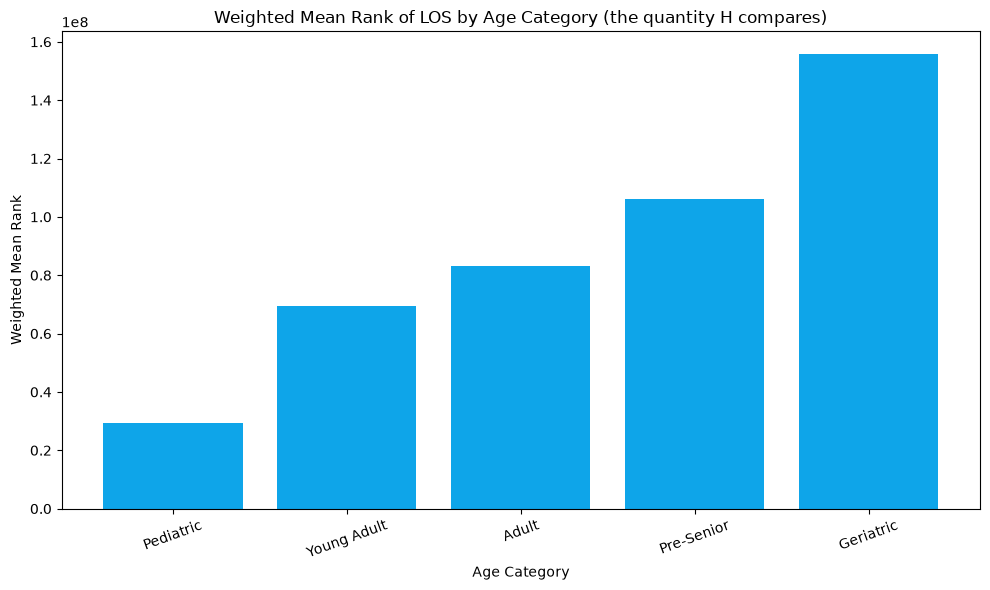

In [18]:
mean_ranks = [g["mean_rank"] for g in h4_result["group_statistics"]]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(short, mean_ranks, color="#0EA5E9")
ax.set_xlabel("Age Category")
ax.set_ylabel("Weighted Mean Rank")
ax.set_title("Weighted Mean Rank of LOS by Age Category (the quantity H compares)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

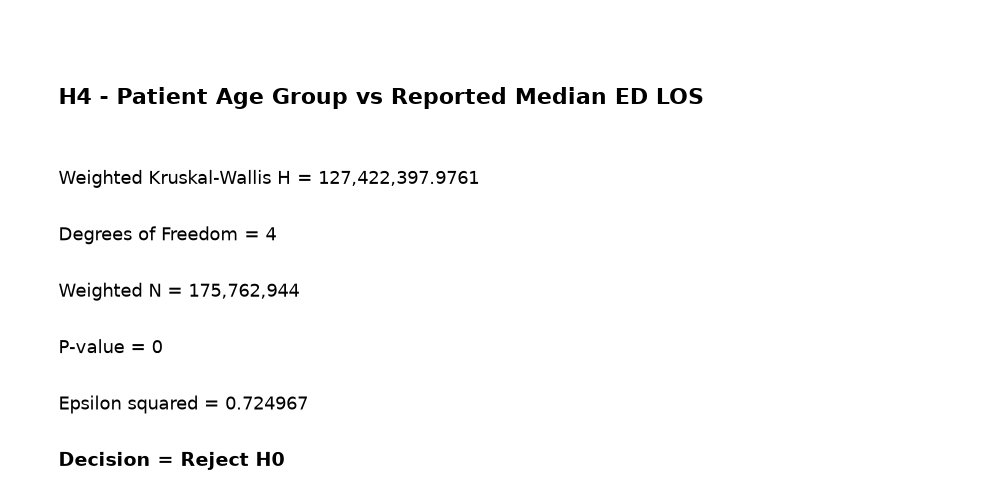

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

decision = "Reject H0" if p_value < ALPHA else "Fail to Reject H0"

ax.text(0.05, 0.80, "H4 - Patient Age Group vs Reported Median ED LOS",
        fontsize=16, fontweight="bold")
ax.text(0.05, 0.63, f"Weighted Kruskal-Wallis H = {h4_result['h_statistic']:,.4f}", fontsize=13)
ax.text(0.05, 0.51, f"Degrees of Freedom = {h4_result['degrees_of_freedom']}", fontsize=13)
ax.text(0.05, 0.39, f"Weighted N = {h4_result['weighted_n']:,}", fontsize=13)
ax.text(0.05, 0.27, f"P-value = {p_value:.6g}", fontsize=13)
ax.text(0.05, 0.15, f"Epsilon squared = {epsilon_squared:.6f}", fontsize=13)
ax.text(0.05, 0.03, f"Decision = {decision}", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [20]:
from backend.analytics.hypothesis_testing import run_h4_test

api = run_h4_test()

print("NOTEBOOK vs PRODUCTION ENGINE")
print("=" * 80)
print(f"{'metric':22} {'notebook':>22} {'backend':>22}")
print(f"{'H':22} {h4_result['h_statistic']:>22,.4f} {api['h_statistic']:>22,.4f}")
print(f"{'weighted N':22} {h4_result['weighted_n']:>22,} {api['weighted_n']:>22,}")
print(f"{'epsilon squared':22} {epsilon_squared:>22.6f} {api['epsilon_squared']:>22.6f}")
print(f"{'decision':22} {decision:>22} {api['decision']:>22}")

NOTEBOOK vs PRODUCTION ENGINE
metric                               notebook                backend
H                            127,422,397.9761       127,422,397.9761
weighted N                        175,762,944            175,762,944
epsilon squared                      0.724967               0.724967
decision                            Reject H0              Reject H₀
